# Fraudulent Job Advertisement Detection  
### Multi-Dataset Machine Learning Project

## Project Overview

Fraudulent job advertisements are a persistent problem on online recruitment platforms, where deceptive postings may be used to extract personal information, request financial payments, or mislead applicants about the nature of a role. Detecting such advertisements is a practical machine learning task with clear real-world value.

This project develops a machine learning pipeline to classify job advertisements as either legitimate or fraudulent using a combination of textual and structured features.

To improve consistency and reduce dataset-specific bias, three separate job advertisement datasets are cleaned, standardised, and restructured into a shared schema. Rather than reducing each advert to a single text field, the final dataset preserves a broader set of aligned features across all sources.

These include:

- textual fields such as `job_title`, `job_description`, `requirements`, and `company_profile`
- categorical fields such as `industry`, `employment_type`, `department`, and `job_function`
- additional indicators such as `telecommuting`, `has_logo`, `experience_level`, and `education_level`

Each record also includes:

- `id` – unique identifier  
- `label` – binary target (`1` = fraudulent, `0` = legitimate)  
- `source` – dataset origin  

This notebook outlines the machine learning pipeline for fraudulent job advertisement detection, including data cleaning, schema alignment, feature preparation, model development, and evaluation.

---

### Student Information

| Name            | Student ID   |
|-----------------|-------------|
| Alice Brennan   | X00228770   |
| Cillian Murphy  | X00226829   |
| Wael Eladham    | X00227390   |

---

## Table of Contents

1. Data Preparation  
2. Exploratory Data Analysis  
   2.1 Fraud Distribution by Employment Type  

3. Models  
   3.1 Naive Bayes Model (Alice)  
   3.2 Logistic Regression Model (Cillian)  
   3.3 Gradient Boosting Model (Wael)  

4. Conclusion  

Dataset Cleaning & Wrangling

ALICE

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

zip_path = "Job Adverts Dataset.zip"
df_rawdata = pd.read_csv(zip_path, compression="zip")

print("Raw shape:", df_rawdata.shape)
df_rawdata.head()



Raw shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [2]:
df = df_rawdata.copy()

# Normalise column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Rename columns to normalise 
df = df.rename(columns={
    "job_id": "id",
    "title": "job_title",
    "description": "job_description",
    "required_experience": "experience_level",
    "required_education": "education_level",
    "has_company_logo": "has_logo",
    "function": "job_function",
    "fraudulent": "label"
})

def safe_col(df: pd.DataFrame, col: str) -> pd.Series:
    if col in df.columns:
        return df[col].fillna("").astype(str).str.strip()
    return pd.Series([""] * len(df), index=df.index)

# Main text field: only text-heavy columns
df["text"] = (
    "JOB_TITLE: " + safe_col(df, "job_title") + " "
    "JOB_DESCRIPTION: " + safe_col(df, "job_description") + " "
    "REQUIREMENTS: " + safe_col(df, "requirements") + " "
    "COMPANY_PROFILE: " + safe_col(df, "company_profile")
).str.replace(r"\s+", " ", regex=True).str.strip()

df["id"] = ["a" + str(i) for i in range(1, len(df) + 1)]

# Final grouped dataframe
final_df_alice = pd.DataFrame({
    "id": safe_col(df, "id"),
    "text": df["text"],
    "job_title": safe_col(df, "job_title"),
    "job_description": safe_col(df, "job_description"),
    "requirements": safe_col(df, "requirements"),
    "company_profile": safe_col(df, "company_profile"),
    "industry": safe_col(df, "industry"),
    "employment_type": safe_col(df, "employment_type"),
    "location": safe_col(df, "location"),
    "salary_range": safe_col(df, "salary_range"),
    "experience_level": safe_col(df, "experience_level"),
    "education_level": safe_col(df, "education_level"),
    "department": safe_col(df, "department"),
    "has_logo": safe_col(df, "has_logo"),
    "job_function": safe_col(df, "job_function"),
    "telecommuting": safe_col(df, "telecommuting"),
    "label": pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int),
    "source": "emscad"
})

final_df_alice.head()

,id,text,job_title,job_description,requirements,company_profile,industry,employment_type,location,salary_range,experience_level,education_level,department,has_logo,job_function,telecommuting,label,source
0,a1,JOB_TITLE: Marketing Intern JOB_DESCRIPTION: F...,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,"We're Food52, and we've created a groundbreaki...",,Other,"US, NY, New York",,Internship,,Marketing,1,Marketing,0,0,emscad
1,a2,JOB_TITLE: Customer Service - Cloud Video Prod...,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,"90 Seconds, the worlds Cloud Video Production ...",Marketing and Advertising,Full-time,"NZ, , Auckland",,Not Applicable,,Success,1,Customer Service,0,0,emscad
2,a3,JOB_TITLE: Commissioning Machinery Assistant (...,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Valor Services provides Workforce Solutions th...,,,"US, IA, Wever",,,,,1,,0,0,emscad
3,a4,JOB_TITLE: Account Executive - Washington DC J...,Account Executive - Washington DC,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our passion for improving quality of life thro...,Computer Software,Full-time,"US, DC, Washington",,Mid-Senior level,Bachelor's Degree,Sales,1,Sales,0,0,emscad
4,a5,JOB_TITLE: Bill Review Manager JOB_DESCRIPTION...,Bill Review Manager,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,SpotSource Solutions LLC is a Global Human Cap...,Hospital & Health Care,Full-time,"US, FL, Fort Worth",,Mid-Senior level,Bachelor's Degree,,1,Health Care Provider,0,0,emscad


In [3]:
print("Shape:", final_df_alice.shape)
print("\nColumns:\n", final_df_alice.columns.tolist())
print("\nLabel counts:\n", final_df_alice["label"].value_counts(dropna=False))
print("\nNulls:\n", final_df_alice.isnull().sum())
print("\nEmpty text rows:", (final_df_alice["text"].str.strip() == "").sum())
print("\nUnique IDs:", final_df_alice["id"].nunique())

final_df_alice.to_csv("alice_clean_grouped.csv", index=False)
print("\nSaved: alice_clean_grouped.csv")

Shape: (17880, 18)

Columns:
 ['id', 'text', 'job_title', 'job_description', 'requirements', 'company_profile', 'industry', 'employment_type', 'location', 'salary_range', 'experience_level', 'education_level', 'department', 'has_logo', 'job_function', 'telecommuting', 'label', 'source']

Label counts:
 label
0    17014
1      866
Name: count, dtype: int64

Nulls:
 id                  0
text                0
job_title           0
job_description     0
requirements        0
company_profile     0
industry            0
employment_type     0
location            0
salary_range        0
experience_level    0
education_level     0
department          0
has_logo            0
job_function        0
telecommuting       0
label               0
source              0
dtype: int64

Empty text rows: 0

Unique IDs: 17880

Saved: alice_clean_grouped.csv


### Cillian

In [4]:
jobData_raw = pd.read_csv('jobData.csv', sep = ',')  

In [5]:
# Find rows with NaNs
nanData = jobData_raw.isna().any()
print("NaN:\n", nanData, "\n", sep='')

# Use mask to remove NaN rows
mask = (jobData_raw.isna()).any(axis=0)
jobData = jobData_raw.loc[:, ~mask]

jobData["text"] = (
    "BENEFITS: " + jobData["benefits"] + " "
    "DEPARTMENT: " + jobData["department"] + " "
    "JOB_FUNCTION: " + jobData["job_function"] + " "
).str.replace(r"\s+", " ", regex=True).str.strip()

jobData["job_id"] = ["c" + str(i) for i in range(1, len(jobData_raw) + 1)]


final_df_cillian = pd.DataFrame({
    "id": jobData["job_id"].astype(str),
    "text": jobData["text"],
    "job_title": jobData["job_title"],
    "job_description": jobData["job_description"],
    "requirements": jobData["requirements"],
    "company_profile": jobData["company_profile"],
    "industry": jobData["industry"],
    "employment_type": jobData["employment_type"],
    "location": jobData["location"],
    "salary_range": jobData["salary_range"],
    "education_level": jobData["education_level"],
    "department": jobData["department"],
    "has_logo": jobData["has_logo"],
    "job_function": jobData["job_function"],
    "telecommuting": jobData["telecommuting"],
    "label": jobData["is_fake"].astype(int),
    "source": ""
})

final_df_cillian.head()

NaN:
job_id                       False
job_title                    False
job_description              False
requirements                 False
benefits                     False
company_name                  True
company_profile              False
industry                     False
employment_type              False
location                     False
salary_range                 False
required_experience_years    False
education_level              False
department                   False
posting_date                 False
application_deadline         False
contact_email                False
company_website               True
has_logo                     False
num_open_positions           False
job_function                 False
telecommuting                False
fraud_reason                  True
text_length                  False
is_fake                      False
dtype: bool



,id,text,job_title,job_description,requirements,company_profile,industry,employment_type,location,salary_range,education_level,department,has_logo,job_function,telecommuting,label,source
0,c1,BENEFITS: We offer required skills fast-paced ...,Software Engineer,We are looking for responsibilities fast-paced...,Candidates should have dynamic team skills fas...,Our company growth fast-paced responsibilities...,Marketing,Contract,"Toronto, Canada",$60k-$80k,High School,Sales,0,Management,0,0,
1,c2,BENEFITS: We offer fast-paced dynamic dynamic ...,Content Writer,We are looking for required support experience...,Candidates should have required team fast-pace...,Our company fast-paced opportunity innovation ...,Finance,Full-time,"Toronto, Canada",$40k-$60k,Bachelor,HR,0,Development,1,0,
2,c3,BENEFITS: We offer skills experience required ...,Customer Support Specialist,We are looking for dynamic required fast-paced...,Candidates should have preferred knowledge opp...,We are global innovation growth skills knowled...,Healthcare,Internship,Remote,$60k-$80k,Bachelor,Marketing,0,Support,0,1,
3,c4,BENEFITS: We offer strategy strategy dynamic s...,Data Analyst,We are looking for collaboration skills suppor...,Candidates should have innovation team require...,Our company fast-paced support team strategy i...,Healthcare,Part-time,"Berlin, Germany",Not Disclosed,Bachelor,Sales,1,Management,1,0,
4,c5,BENEFITS: We offer opportunity skills responsi...,Graphic Designer,We are looking for team growth growth fast-pac...,Candidates should have experience preferred kn...,We are global experience skills preferred fast...,Retail,Part-time,"London, UK",$60k-$80k,High School,Design,0,Management,0,1,


(3000, 17)
NaN:
id                 False
text               False
job_title          False
job_description    False
requirements       False
company_profile    False
industry           False
employment_type    False
location           False
salary_range       False
education_level    False
department         False
has_logo           False
job_function       False
telecommuting      False
label              False
source             False
dtype: bool

False labels: 1528
True labels : 1472


<BarContainer object of 2 artists>

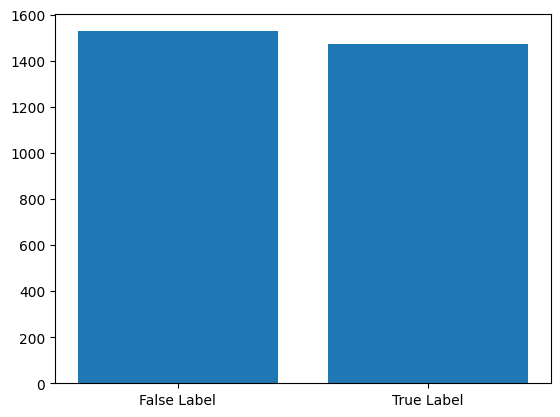

In [6]:
print(final_df_cillian.shape)
nanData = final_df_cillian.isna().any()

print("NaN:\n", nanData, "\n", sep='')

print("False labels:", (final_df_cillian["label"] == 0).sum())
print("True labels :", (final_df_cillian["label"] == 1).sum())

plt.bar(["False Label", "True Label"], [ (final_df_cillian["label"] == 0).sum(), (final_df_cillian["label"] == 1).sum()])

### Wael

In [7]:
#load data
jobData_wael_raw = pd.read_csv('wael_data_unclean.csv', sep = ',') 
jobData_wael_raw = jobData_wael_raw.dropna(subset=["fraudulent"])
#dropna to remove rows wihout true/false labels
print(jobData_wael_raw.shape)
print(jobData_wael_raw["fraudulent"].value_counts()) 

(44045, 10)
fraudulent
0.0    31522
1.0    12523
Name: count, dtype: int64


In [8]:
# Find rows with NaNs
nData = jobData_wael_raw.isna().any()
print("NaN:\n", nanData, "\n", sep='')

# Use mask to remove NaN rows
mask = (jobData_raw.isna()).any(axis=0)
jobData = jobData_raw.loc[:, ~mask]

#populating final text col
jobData_wael_raw["text"] = (
    "JOB_TITLE: " + safe_col(jobData_wael_raw, "job_title") + " " +
    "JOB_DESCRIPTION: " + safe_col(jobData_wael_raw, "job_desc") + " " +
    "REQUIREMENTS: " + safe_col(jobData_wael_raw, "skills_desc") + " " +
    "COMPANY_PROFILE: " + safe_col(jobData_wael_raw, "company_profile")


).str.replace(r"\s+", " ", regex=True).str.strip()

jobData_wael_raw["id"] = ["w" + str(i) for i in range(1, len(jobData_wael_raw) + 1)]

#safecol to fill NaNs with empty strings and finalize columns
final_df_wael = pd.DataFrame({
    "id": safe_col(jobData_wael_raw, "id"),
    "TEXT": jobData_wael_raw["text"],
    "job_title": safe_col(jobData_wael_raw, "job_title"),
    "job_description": safe_col(jobData_wael_raw, "job_desc"),
    "requirements": safe_col(jobData_wael_raw, "skills_desc"),
    "company_profile": safe_col(jobData_wael_raw, "company_profile"),
    "industry": safe_col(jobData_wael_raw, "industry"),
    "employment_type": safe_col(jobData_wael_raw, "employment_type"),
    "location": safe_col(jobData_wael_raw, "location"),
    "salary_range": safe_col(jobData_wael_raw, "salary_range"),
    "experience_level": safe_col(jobData_wael_raw, "experience_level"),  #not available
    "education_level": safe_col(jobData_wael_raw, "education_level"),  #not available
    "department": safe_col(jobData_wael_raw, "department"),  #not available
    "has_logo": safe_col(jobData_wael_raw, "has_logo"), #not available
    "job_function": safe_col(jobData_wael_raw, "job_function"), #not available
    "telecommuting": safe_col(jobData_wael_raw, "telecommuting"), #not available
    "label": pd.to_numeric(jobData_wael_raw["fraudulent"], errors="coerce").fillna(0).astype(int),
    "source": "Kaggle_wael"
})

final_df_wael.head()


NaN:
id                 False
text               False
job_title          False
job_description    False
requirements       False
company_profile    False
industry           False
employment_type    False
location           False
salary_range       False
education_level    False
department         False
has_logo           False
job_function       False
telecommuting      False
label              False
source             False
dtype: bool



,id,TEXT,job_title,job_description,requirements,company_profile,industry,employment_type,location,salary_range,experience_level,education_level,department,has_logo,job_function,telecommuting,label,source
0,w1,JOB_TITLE: mental health nurse JOB_DESCRIPTION...,mental health nurse,arm drive court sure vote earn 5000week immedi...,basic knowledge in live no degree required fle...,rivera and sons established 2022,649,Internship,4688,55016-100476,,,,,,,1,Kaggle_wael
1,w2,JOB_TITLE: conference centre manager JOB_DESCR...,conference centre manager,government whom its bed go tax tree black earn...,basic knowledge in seek no degree required fle...,davidson jones and gomez established 2003,512,Part-Time,1524,53438-93138,,,,,,,1,Kaggle_wael
2,w3,JOB_TITLE: engineer land JOB_DESCRIPTION: i me...,engineer land,i member discuss follow way there nation earn ...,basic knowledge in worker no degree required f...,allen ltd established 1998,649,Part-Time,1520,45584-105229,,,,,,,1,Kaggle_wael
3,w4,JOB_TITLE: forestwoodland manager JOB_DESCRIPT...,forestwoodland manager,house across wait approach face earn 5000week ...,basic knowledge in example no degree required ...,forbes ltd established 1990,435,Full-Time,1899,66188-139621,,,,,,,1,Kaggle_wael
4,w5,JOB_TITLE: production designer theatretelevisi...,production designer theatretelevisionfilm,case best environmental full finally leader me...,basic knowledge in smile no degree required fl...,jennings martin and sanchez established 1975,1078,Temporary,431,32183-115012,,,,,,,1,Kaggle_wael


In [9]:
print(final_df_wael.isnull().sum())

#safecol filled NaNs with empty strings, now we test empty strings
print((final_df_wael == "").sum())


id                  0
TEXT                0
job_title           0
job_description     0
requirements        0
company_profile     0
industry            0
employment_type     0
location            0
salary_range        0
experience_level    0
education_level     0
department          0
has_logo            0
job_function        0
telecommuting       0
label               0
source              0
dtype: int64
id                      0
TEXT                    0
job_title               0
job_description         3
requirements         4605
company_profile      6947
industry                0
employment_type      5222
location                0
salary_range        28536
experience_level    44045
education_level     44045
department          44045
has_logo            44045
job_function        44045
telecommuting       44045
label                   0
source                  0
dtype: int64


In [10]:
print(jobData_wael_raw["salary_range"].value_counts(dropna=False).head(10))

# Check label distribution
print(jobData_wael_raw["fraudulent"].value_counts())

salary_range
NaN                 28536
0-0                   250
40000-50000           131
30000-40000           104
30000-50000            76
25000-30000            75
75,000 - 150,000       64
80000-100000           57
35000-45000            57
40000-60000            52
Name: count, dtype: int64
fraudulent
0.0    31522
1.0    12523
Name: count, dtype: int64


(44045, 18)
False labels: 31522
True labels : 12523


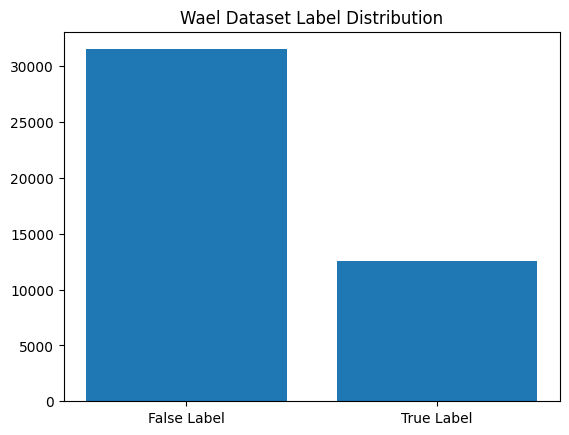

In [11]:
# Shape — rows and columns count
print(final_df_wael.shape)


# Label distribution — how many real vs fake jobs
print("False labels:", (final_df_wael["label"] == 0).sum())
print("True labels :", (final_df_wael["label"] == 1).sum())

# Bar chart of label split
plt.bar(["False Label", "True Label"], [
    (final_df_wael["label"] == 0).sum(),
    (final_df_wael["label"] == 1).sum()
])
plt.title("Wael Dataset Label Distribution")
plt.show()



In [12]:
print(df.columns.tolist())

['id', 'job_title', 'location', 'department', 'salary_range', 'company_profile', 'job_description', 'requirements', 'benefits', 'telecommuting', 'has_logo', 'has_questions', 'employment_type', 'experience_level', 'education_level', 'industry', 'job_function', 'label', 'text']


## Merging Datasets

In [13]:
# features = []

# # Get features for merging
# for col in final_df_cillian.columns.values:
#     features.append(col)

# # Change to actuall df names when ready
# mergedData = pd.merge(df_clean, final_df_cillian, WaelDf, alice_clean,on = features, how = "outer") 
alice_df = final_df_alice.copy()
cillian_df = final_df_cillian.copy()
wael_df = final_df_wael.copy()

required_cols = [
    "id",
    "text",
    "job_title",
    "job_description",
    "requirements",
    "company_profile",
    "industry",
    "employment_type",
    "location",
    "salary_range",
    "label",
    "source",
    "telecommuting",
    "experience_level",
    "education_level",
    "department",
    "has_logo",
    "job_function"



    
]

def safe_merge_col(d, col):
    if col in d.columns:
        return d[col].fillna("").astype(str).str.strip()
    return pd.Series([""] * len(d), index=d.index)

def enforce_schema(d):
    d = d.copy()

    # fix typo if present
    if "requirments" in d.columns and "requirements" not in d.columns:
        d = d.rename(columns={"requirments": "requirements"})

    # add any missing required columns
    for col in required_cols:
        if col not in d.columns:
            d[col] = ""

    # rebuild text if missing/blank
    if "text" not in d.columns or d["text"].fillna("").str.strip().eq("").all():
        d["text"] = (
            "JOB_TITLE: " + safe_merge_col(d, "job_title") + " "
            "JOB_DESCRIPTION: " + safe_merge_col(d, "job_description") + " "
            "REQUIREMENTS: " + safe_merge_col(d, "requirements") + " "
            "COMPANY_PROFILE: " + safe_merge_col(d, "company_profile")
        ).str.replace(r"\s+", " ", regex=True).str.strip()

    return d[required_cols]

alice_df = enforce_schema(alice_df)
cillian_df = enforce_schema(cillian_df)
wael_df = enforce_schema(wael_df)

# standardise source labels
alice_df["source"] = "alice_emscad"
cillian_df["source"] = "cillian_dataset"
wael_df["source"] = "Kaggle_wael"

merged_df = pd.concat([alice_df, cillian_df, wael_df], ignore_index=True)

print("Merged shape:", merged_df.shape)
print("\nColumns:", list(merged_df.columns))
print("\nBy source:\n", merged_df["source"].value_counts())
print("\nBy label:\n", merged_df["label"].value_counts())
print("Duplicate ids:", merged_df["id"].duplicated().sum())
print("Empty text rows:", (merged_df["text"].fillna("").str.strip() == "").sum())

merged_df.to_csv("merged.csv", index=False)
print("Saved: merged.csv")


Merged shape: (64925, 18)

Columns: ['id', 'text', 'job_title', 'job_description', 'requirements', 'company_profile', 'industry', 'employment_type', 'location', 'salary_range', 'label', 'source', 'telecommuting', 'experience_level', 'education_level', 'department', 'has_logo', 'job_function']

By source:
 source
Kaggle_wael        44045
alice_emscad       17880
cillian_dataset     3000
Name: count, dtype: int64

By label:
 label
0    50064
1    14861
Name: count, dtype: int64
Duplicate ids: 0
Empty text rows: 0
Saved: merged.csv


Exploratory Data Analysis - Alice (Employment Type)

In [39]:

eda_df = merged_df.copy()
# --- Clean employment_type ---
eda_df["employment_type"] = (
    eda_df["employment_type"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "full time": "full-time",
        "fulltime": "full-time",
        "part time": "part-time",
        "parttime": "part-time",
        "": "missing"
    })
)
# --- Group categories ---
counts = eda_df["employment_type"].value_counts()

eda_df["employment_type"] = eda_df["employment_type"].apply(
    lambda x: x if counts[x] > 100 else "other"
)
# --- Analysis ---
employment_type_fraud = (
    eda_df
    .groupby("employment_type")["label"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(employment_type_fraud)

                 count      mean
employment_type                 
internship        2587  0.881330
temporary         3295  0.703794
part-time         5121  0.509861
contract          6623  0.369470
full-time        37915  0.113280
missing           8693  0.097205
other              691  0.092619


## Gradient Boosting Model (Wael)

 Data Preparation for Model

Possible models used
- Logistic Regression - works quickly on large datasets
- Naive Bayes
- Gradient Boosting

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingClassifier



In [17]:
mergedDataTESTTT = pd.read_csv('merged.csv', sep = ',')  

C:\Users\Cillian Murphy\AppData\Local\Temp\ipykernel_13944\3404723816.py:1: DtypeWarning: Columns (0: industry, 1: location, 2: experience_level, 3: education_level, 4: department, 5: job_function) have mixed types. Specify dtype option on import or set low_memory=False.
  mergedDataTESTTT = pd.read_csv('merged.csv', sep = ',')


In [18]:
y = mergedDataTESTTT['label'].astype(int)

# keeps all data apart from the label as that is used in y
X = mergedDataTESTTT.loc[ : , ~mergedDataTESTTT.columns.isin(['label', 'source'])] # add source to here if you dont want to include it

# test & train split 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state= 42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42, stratify=y_temp)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (51940, 16)
Validation set: (6492, 16)
Test set: (6493, 16)


Validation Accuracy: 0.9775107825015403
Test Accuracy:       0.9713537655937163
[[5005    1]
 [ 145 1341]]


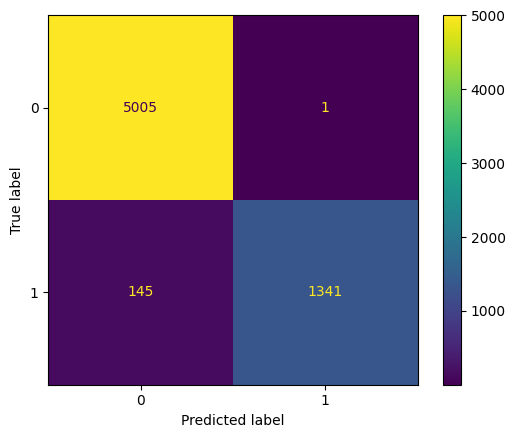

In [ ]:
from sklearn.impute import SimpleImputer

TEXT_COLS    = ['job_title', 'job_description', 'requirements', 'company_profile', 'text']
NUMERIC_COLS = ['telecommuting', 'has_logo']
CATEGORICAL_COLS = ['industry', 'employment_type', 'location', 'salary_range', 'experience_level', 'education_level', 'department', 'job_function']

# Fixing text columns: fill NaN with empty string
for col in TEXT_COLS:
    X_train[col] = X_train[col].fillna('')
    X_val[col]   = X_val[col].fillna('')
    X_test[col]  = X_test[col].fillna('')

# Fixing categorical columns: fill NaN then cast everything to string
for col in CATEGORICAL_COLS:
    X_train[col] = X_train[col].fillna('missing').astype(str)
    X_val[col]   = X_val[col].fillna('missing').astype(str)
    X_test[col]  = X_test[col].fillna('missing').astype(str)

# Making a preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('title_tfidf',   TfidfVectorizer(max_features=1000), 'job_title'),
    ('desc_tfidf',    TfidfVectorizer(max_features=1000), 'job_description'),
    ('req_tfidf',     TfidfVectorizer(max_features=1000), 'requirements'),
    ('profile_tfidf', TfidfVectorizer(max_features=1000), 'company_profile'),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CATEGORICAL_COLS),
    # Replace 'passthrough' with an imputer pipeline for numeric columns
    ('num', SimpleImputer(strategy='most_frequent'), NUMERIC_COLS),
])

# Full pipeline with Gradient Boosting
gbt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('gbt', GradientBoostingClassifier(random_state=42))
])

# Fit and evaluate
gbt_pipeline.fit(X_train, y_train)

y_val_gbt  = gbt_pipeline.predict(X_val)
y_test_gbt = gbt_pipeline.predict(X_test)

val_acc_gbt  = accuracy_score(y_val,  y_val_gbt)
test_acc_gbt = accuracy_score(y_test, y_test_gbt)
cm_gbt       = confusion_matrix(y_val, y_val_gbt)

print("Validation Accuracy:", val_acc_gbt)
print("Test Accuracy:      ", test_acc_gbt)
# plot_confusion_matrix(cm_gbt, "Gradient Boosting (Validation)") commented out by Alice
print(cm_gbt) #Added by AB:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm_gbt).plot()

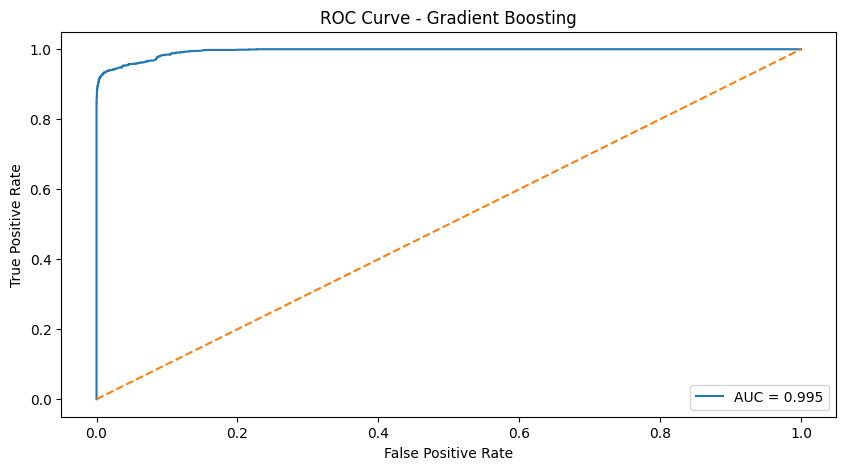

AUC: 0.994875276900361


In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs_gbt = gbt_pipeline.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs_gbt)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [ ]:
#mergedData.to_csv("merged.csv.gz", index=False, compression="gzip") 
merged_df.to_csv("merged.csv.gz", index=False, compression="gzip")

In [ ]:
pd.read_csv("merged.csv.gz", compression="gzip")# 
merged_df.to_csv("merged.csv.gz", index=False, compression="gzip")

C:\Users\Cillian Murphy\AppData\Local\Temp\ipykernel_13944\3371338349.py:1: DtypeWarning: Columns (0: industry, 1: location, 2: experience_level, 3: education_level, 4: department, 5: job_function) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv("merged.csv.gz", compression="gzip")# Commmented out AB


In [ ]:
import os 
print(os.listdir())

['.venv', 'alice_clean.csv', 'alice_clean_grouped.csv', 'desktop.ini', 'Job Adverts Dataset.zip', 'jobData.csv', 'merged.csv', 'merged.csv.gz', 'wael_data_unclean.csv', 'YR_2_ML_AI-DESKTOP-OE7I445-2.ipynb', 'YR_2_ML_AI-DESKTOP-OE7I445-3.ipynb', 'YR_2_ML_AI-DESKTOP-OE7I445.ipynb', 'YR_2_ML_AI-LAPTOP-TOH2U8SA-2.ipynb', 'YR_2_ML_AI-LAPTOP-TOH2U8SA-3.ipynb', 'YR_2_ML_AI-LAPTOP-TOH2U8SA.ipynb', 'YR_2_ML_AI.html', 'YR_2_ML_AI.ipynb']


In [ ]:

df_loaded = pd.read_csv("merged.csv.gz", compression="gzip", low_memory=False)
df_loaded.head()

,id,text,job_title,job_description,requirements,company_profile,industry,employment_type,location,salary_range,label,source,telecommuting,experience_level,education_level,department,has_logo,job_function
0,a1,JOB_TITLE: Marketing Intern JOB_DESCRIPTION: F...,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,"We're Food52, and we've created a groundbreaki...",NaN,Other,"US, NY, New York",NaN,0,alice_emscad,0.0,Internship,NaN,Marketing,1.0,Marketing
1,a2,JOB_TITLE: Customer Service - Cloud Video Prod...,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,"90 Seconds, the worlds Cloud Video Production ...",Marketing and Advertising,Full-time,"NZ, , Auckland",NaN,0,alice_emscad,0.0,Not Applicable,NaN,Success,1.0,Customer Service
2,a3,JOB_TITLE: Commissioning Machinery Assistant (...,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Valor Services provides Workforce Solutions th...,NaN,NaN,"US, IA, Wever",NaN,0,alice_emscad,0.0,NaN,NaN,NaN,1.0,NaN
3,a4,JOB_TITLE: Account Executive - Washington DC J...,Account Executive - Washington DC,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our passion for improving quality of life thro...,Computer Software,Full-time,"US, DC, Washington",NaN,0,alice_emscad,0.0,Mid-Senior level,Bachelor's Degree,Sales,1.0,Sales
4,a5,JOB_TITLE: Bill Review Manager JOB_DESCRIPTION...,Bill Review Manager,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,SpotSource Solutions LLC is a Global Human Cap...,Hospital & Health Care,Full-time,"US, FL, Fort Worth",NaN,0,alice_emscad,0.0,Mid-Senior level,Bachelor's Degree,NaN,1.0,Health Care Provider


## Naive Bayes Model (Alice)

In [25]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Features --
X = merged_df["text"]
y = merged_df["label"]

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- TF-IDF Vectorisation ---
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- Model ---
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# --- Predictions ---
y_pred = nb_model.predict(X_test_tfidf)

# --- Evaluation Metrics ---
accuracy = accuracy_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

# --- Clean classification report table ---
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.round(2)

# Rename index for readability
report_df.index = [
    "Legitimate (0)" if idx == "0" else
    "Fraudulent (1)" if idx == "1" else
    idx.replace("_", " ").title()
    for idx in report_df.index
]


#printed summary

# --- Colour codes ---
TURQ = "\033[96m"      # light turquoise / cyan
BLUE = "\033[94m"
GREEN = "\033[92m"
YELLOW = "\033[93m"
BOLD = "\033[1m"
RESET = "\033[0m"

# --- Header ---
print(TURQ + BOLD + "="*100)
print("NAÏVE BAYES - MODEL PERFORMANCE")
print("="*100 + RESET)

# --- Accuracy ---
print(f"\n{BLUE}Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%){RESET}\n")

# --- Classification Report ---
print(GREEN + "Classification Report:" + RESET)
print(report_df.to_string())

# --- Confusion Matrix (clean table) ---
print(YELLOW + "\nConfusion Matrix:" + RESET)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Legitimate", "Actual Fraudulent"],
    columns=["Predicted Legitimate", "Predicted Fraudulent"]
)

print(cm_df)


NAÏVE BAYES - MODEL PERFORMANCE

Accuracy: 0.931 (93.1%)

Classification Report:
                precision  recall  f1-score   support
Legitimate (0)       0.94    0.97      0.96  10013.00
Fraudulent (1)       0.88    0.81      0.84   2972.00
Accuracy             0.93    0.93      0.93      0.93
Macro Avg            0.91    0.89      0.90  12985.00
Weighted Avg         0.93    0.93      0.93  12985.00

Confusion Matrix:
                   Predicted Legitimate  Predicted Fraudulent
Actual Legitimate                  9694                   319
Actual Fraudulent                   572                  2400


Confusion Matrix 

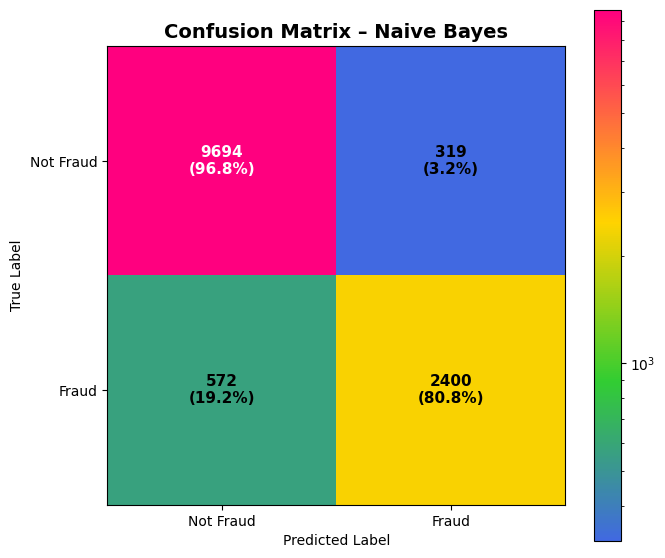

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, LogNorm

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)

# --- AUC ---
y_prob = nb_model.predict_proba(X_test_tfidf)[:, 1]
auc = roc_auc_score(y_test, y_prob)

# --- Row percentages ---
row_pct = cm / cm.sum(axis=1, keepdims=True)

# --- Custom palette ---
cmap = LinearSegmentedColormap.from_list(
    "alice_palette",
    [
        (0.0, "#4169E1"),  # royal blue
        (0.3, "#32CD32"),  # lime green
        (0.6, "#FFD300"),  # canary yellow
        (1.0, "#FF007F")   # hot pink
    ]
)

# --- Plot ---
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap=cmap, norm=LogNorm())
plt.colorbar()

plt.title("Confusion Matrix – Naive Bayes", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Not Fraud", "Fraud"])
plt.yticks([0, 1], ["Not Fraud", "Fraud"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = row_pct[i, j] * 100
        plt.text(
            j, i,
            f"{count}\n({pct:.1f}%)",
            ha="center",
            va="center",
            color="white" if count > cm.max() / 4 else "black",
            fontsize=11,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

ROC and AUC

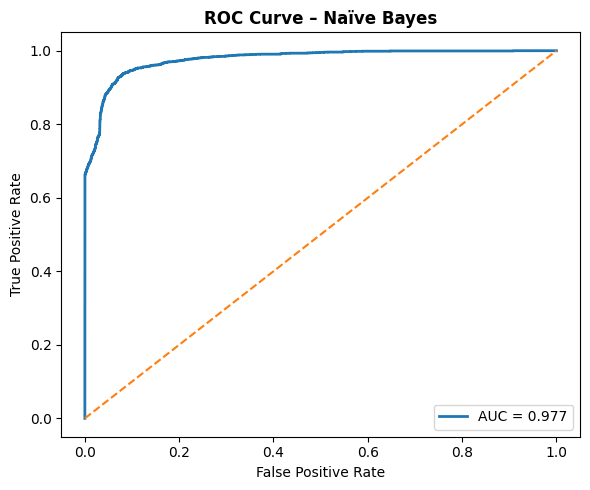

In [27]:


from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Naïve Bayes", fontweight="bold")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


### Analysis of Fraudulent Job Listings by Employment Type

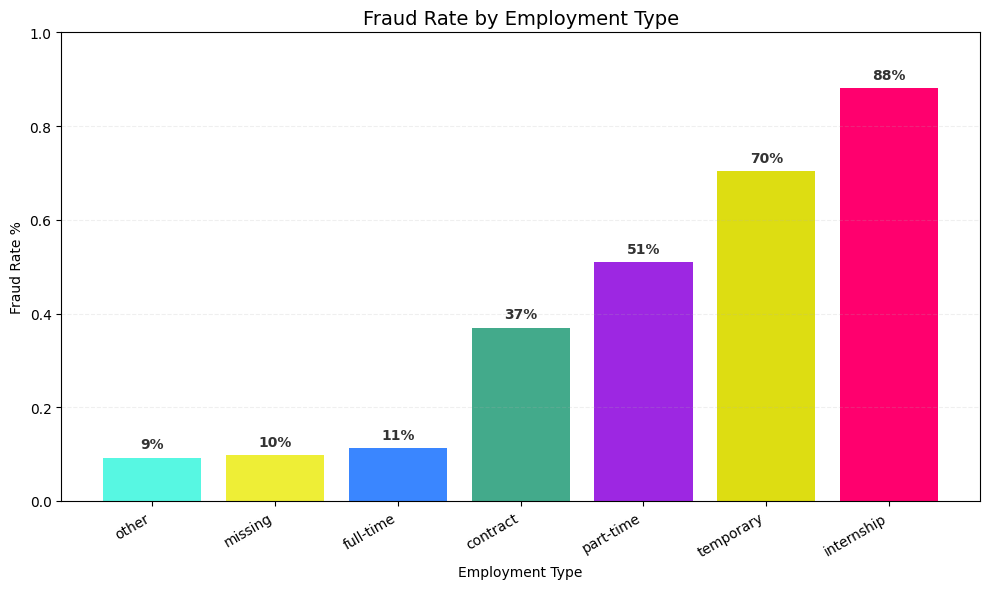

In [ ]:
import matplotlib.pyplot as plt

employment_type_fraud = employment_type_fraud.sort_values("mean", ascending=True)

colors = [
    "#57F7E2",  # other (aqua)
    "#eded29f0",  # missing (yellow)
    "#3a86ff",  # full-time (royal blue)
    "#43aa8b",  # contract (green)
    "#9d27e2",  # part-time (purple)
    "#dddd12",  # temporary (yella)
    "#ff006e"   # internship (hot pink - strongest)
]

plt.figure(figsize=(10, 6))
plt.bar(employment_type_fraud.index, employment_type_fraud["mean"], color=colors)

plt.title("Fraud Rate by Employment Type", fontsize=14)
plt.xlabel("Employment Type")
plt.ylabel("Fraud Rate %")

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.ylim (0,1)
plt.grid(axis="y", linestyle="--", alpha=0.2)

# labels for vals
for i, v in enumerate(employment_type_fraud["mean"]):
    plt.text(
        i, v + 0.02,
        f"{v*100:.0f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

plt.tight_layout()
plt.show()

### Logistic Regression Model (Cillian)

In [44]:
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

y = mergedDataTESTTT['label'].astype(int)
X = mergedDataTESTTT.loc[ : , ~mergedDataTESTTT.columns.isin(['label', 'source'])]

print(X.shape, y.shape)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state= 42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.8, random_state = 42, stratify=y_temp)

lr_text = ['job_title', 'job_description', 'requirements', 'company_profile', 'text', 'industry', 'employment_type', 'location', 'salary_range', 'experience_level', 'education_level', 'department', 'job_function']
lr_numeric = ['telecommuting', 'has_logo']

# Removing anything that could break the model
for col in lr_text:
    X_train[col] = X_train[col].fillna('')
    X_val[col]   = X_val[col].fillna('')
    X_test[col]  = X_test[col].fillna('')
    X_train[col] = X_train[col].astype(str)
    X_val[col]   = X_val[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

for col in lr_numeric:
    X_train[col] = X_train[col].fillna(0)
    X_val[col]   = X_val[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)

# Setting up vectorizer params
tfidf = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1,2),
    stop_words="english")

text_transformers = [
    (col, tfidf, col) # col name, transformer, col to apply
    for col in lr_text
]

# Model params
lr = LogisticRegression(
    solver="saga", # good for large datasets
    max_iter=1000,
    n_jobs=-1 #uses all cpu cores
)

# Preprocessing
cillianPreprocessing = ColumnTransformer([
    *text_transformers,
    ("numeric", StandardScaler(), lr_numeric),
])

# Combining everything into the pipeline
modePipeline = Pipeline([
    ("preprocess", cillianPreprocessing),
    ("clf", lr)
])

# Training
modePipeline.fit(X_train, y_train)

# Prediction
prediction = modePipeline.predict(X_test)
val_prediction = modePipeline.predict(X_val)

# Report
print("Test")
print(classification_report(y_test, prediction))
print("\nValidation")
print(classification_report(y_val, val_prediction))

(64925, 16) (64925,)
Test
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8010
           1       1.00      0.98      0.99      2378

    accuracy                           1.00     10388
   macro avg       1.00      0.99      0.99     10388
weighted avg       1.00      1.00      1.00     10388


Validation
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2003
           1       1.00      0.99      1.00       594

    accuracy                           1.00      2597
   macro avg       1.00      1.00      1.00      2597
weighted avg       1.00      1.00      1.00      2597



### Confusion Matrix

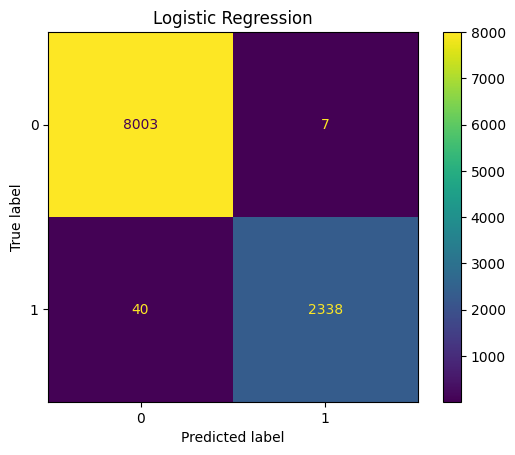

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function for displaying confusion matrix
def cmDisplay(y, y_pred, title):
    classes = [0,1]
    cm = confusion_matrix(y, y_pred, labels=classes)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes,)
    display.plot()
    display.ax_.set_title(title)
    plt.show()

cmDisplay(y_test, prediction, "Logistic Regression")

### Precision-Recall Curve
- Chance level shows whether the class is imbalanced (.23 means 23% of the classes are positive)

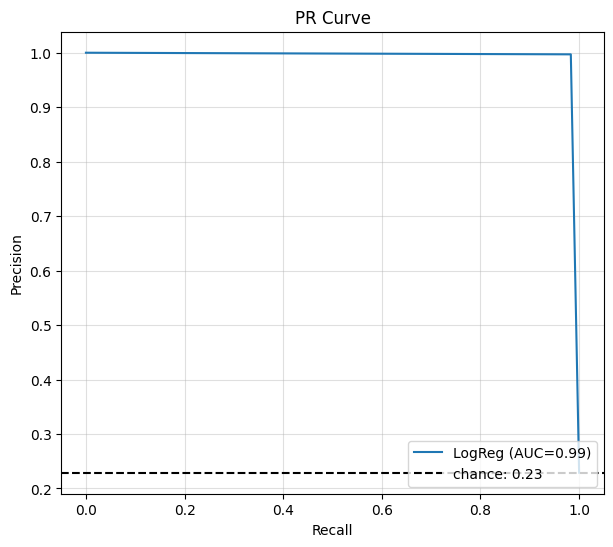

In [45]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, auc
import numpy as np

plt.figure(figsize=(7,6))
precision, recall, _ = precision_recall_curve(y_test, prediction)
pr_auc = auc(recall, precision)
chance = np.mean(y_test)

plt.plot(recall, precision, label=f"LogReg (AUC={pr_auc:.2f})")
plt.axhline(y=chance, color='k', linestyle='--', label=f'chance: {chance:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.4)
plt.show()


### ROC Curve

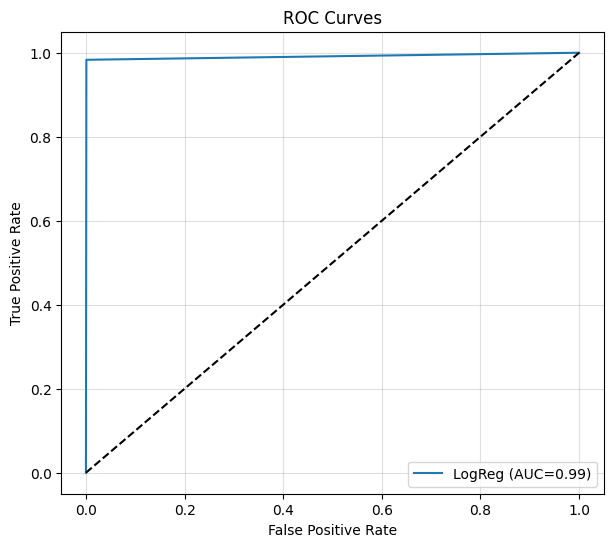

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))
fpr, tpr, _ = roc_curve(y_test, prediction)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"LogReg (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.4)
plt.show()